In [1]:
import os
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.colors import BoundaryNorm
from PIL import Image

import torch
from torchvision import transforms
from torch.utils.data import Dataset

In [2]:
def read_part_labels(path):
    with open(path) as f:
        labels = [l.strip() for l in f if l.strip()]
        return labels

def find_part_masks(image_path, class_to_id, mask_dir, labels):
    """Return (class_id, {part_name: mask_path}) or None"""
    image_name = os.path.splitext(os.path.basename(image_path))[0]
    class_name = os.path.basename(os.path.dirname(image_path))
    class_id = class_to_id[class_name]
    class_mask_dir = os.path.join(mask_dir, str(class_id))
    if not os.path.isdir(class_mask_dir):
        return None

    masks = {}
    for f in os.listdir(class_mask_dir):
        if image_name in f:
            for lbl in labels:
                if lbl in f:
                    masks[lbl] = os.path.join(class_mask_dir, f)

    return (class_id, masks) if masks else None


def visualize(*, labels=None, **images):
    """Plot images + masks in one row with perfect discrete colormap legend (unlimited classes)"""
    n = len(images)
    plt.figure(figsize=(4 + 4 * n, 6))  # auto-scale width
    for i, (name, data) in enumerate(images.items(), 1):
        plt.subplot(1, n, i)
        plt.xticks([]); plt.yticks([])
        plt.title(name.replace("_", " ").title(), fontsize=14)
        arr = np.asarray(data)

        # ---------------- IMAGE ----------------
        if name == "image":
            # Handle CHW → HWC
            if arr.ndim == 3 and arr.shape[0] == 3:
                arr = arr.transpose(1, 2, 0)
            # Normalize to 0–1 if needed
            if arr.max() > 1.0:
                arr = arr / 255.0
            plt.imshow(arr)
            continue

        # ---------------- MASK PLOTTING ----------------
        # Supports unlimited integer classes with exact color mapping
        mask = arr.squeeze()  # H x W
        cmap = plt.get_cmap("turbo")  # # Alternatives: "nipy_spectral", "hsv", "jet", "gist_ncar"        
        bounds = np.arange(-0.5, mask.max() + 1.5, 1)
        norm = BoundaryNorm(bounds, cmap.N)
        plt.imshow(mask, cmap=cmap, norm=norm, interpolation="nearest")

        # ---------------- LEGEND ----------------
        # Exact color match between image and legend
        handles = [
            Patch(
                color=cmap(norm(v)),  # exact color used in the image
                label=labels[v] if v < len(labels) else f"Class {v} (unknown)"
            )
            for v in np.unique(mask)
        ]

        plt.legend(
            handles=handles, title="Classes", bbox_to_anchor=(1.05, 1),
            loc="upper left", borderaxespad=0.0, fontsize=10, title_fontsize=12
        )

    plt.tight_layout()
    plt.show()


In [3]:
class PartWholeDataset(Dataset):
    def __init__(self, dataset_path, image_size=320):
        self.image_size = image_size

        # -------- Paths --------
        self.img_dir = os.path.join(dataset_path, "images")
        self.mask_dir = os.path.join(dataset_path, "AnnotationMasksPerclass")

        # -------- Labels --------
        self.labels = ["background"] + read_part_labels(
            os.path.join(dataset_path, "part_labels.txt")
        )
        self.num_parts = len(self.labels)

        # -------- Classes --------
        classes = pd.read_csv(
            os.path.join(dataset_path, "classes.txt"),
            sep=" ", header=None, names=["id", "name"]
        )
        self.class_to_id = {
            name: idx + 1 for idx, name in enumerate(classes["name"])
        }

        # -------- Images --------
        images = pd.read_csv(
            os.path.join(dataset_path, "images.txt"),
            sep=" ", header=None, names=["id", "name"]
        )

        # Build image → (class_id, mask_dict) mapping ONCE
        self.samples = []
        for name in images["name"]:
            img_path = os.path.join(self.img_dir, name)
            info = find_part_masks(
                img_path, self.class_to_id, self.mask_dir, self.labels
            )
            if info:
                self.samples.append((img_path, *info))

        # -------- Transforms --------
        self.img_transform = transforms.Compose([
            transforms.Resize(
                (image_size, image_size),
                interpolation=transforms.InterpolationMode.BILINEAR
            ),
            transforms.ToTensor(),
        ])

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, class_id, mask_dict = self.samples[idx]

        # Load image
        img = Image.open(img_path).convert("RGB")
        img = self.img_transform(img)

        # Combined mask
        mask = np.zeros((self.image_size, self.image_size), dtype=np.int64)
        for label_idx, label in enumerate(self.labels):
            path = mask_dict.get(label)
            if not path:
                continue

            pm = Image.open(path).convert("L")
            pm = pm.resize((self.image_size, self.image_size), Image.NEAREST)
            mask[np.array(pm) > 127] = label_idx
        mask = torch.from_numpy(mask)
        
        return img, mask, class_id


In [4]:
IMAGE_SIZE = 320
dataset_path = r'/home/c/choton/beemachine/datasets/Others/CUB_200_2011/'

# Paths
imgs_dir = os.path.join(dataset_path, r'images')
mask_dir = os.path.join(dataset_path, r'AnnotationMasksPerclass')
part_label_path = os.path.join(dataset_path, r'part_labels.txt')
classes_path = os.path.join(dataset_path, r"classes.txt")
train_test_path = os.path.join(dataset_path, r"train_test_split.txt")
image_names_path = os.path.join(dataset_path, r"images.txt")

In [5]:
classes_pd = pd.read_csv(classes_path, header=None, sep=" ")
classes_pd.columns = ["id", "name"]
class_names = list(classes_pd['name'])
image_names = pd.read_csv(image_names_path, header=None, sep=" ")
image_names.columns = ["id", "name"]
labels = read_part_labels(part_label_path)
labels.insert(0, 'background')
labels

['background',
 'body',
 'head',
 'neck',
 'beak',
 'tail',
 'right_wing',
 'left_wing',
 'right_leg',
 'left_leg',
 'right_eye',
 'left_eye']

In [6]:
full_dataset = PartWholeDataset(image_size=IMAGE_SIZE, dataset_path=dataset_path)
len(full_dataset)

1888

class_id: 2


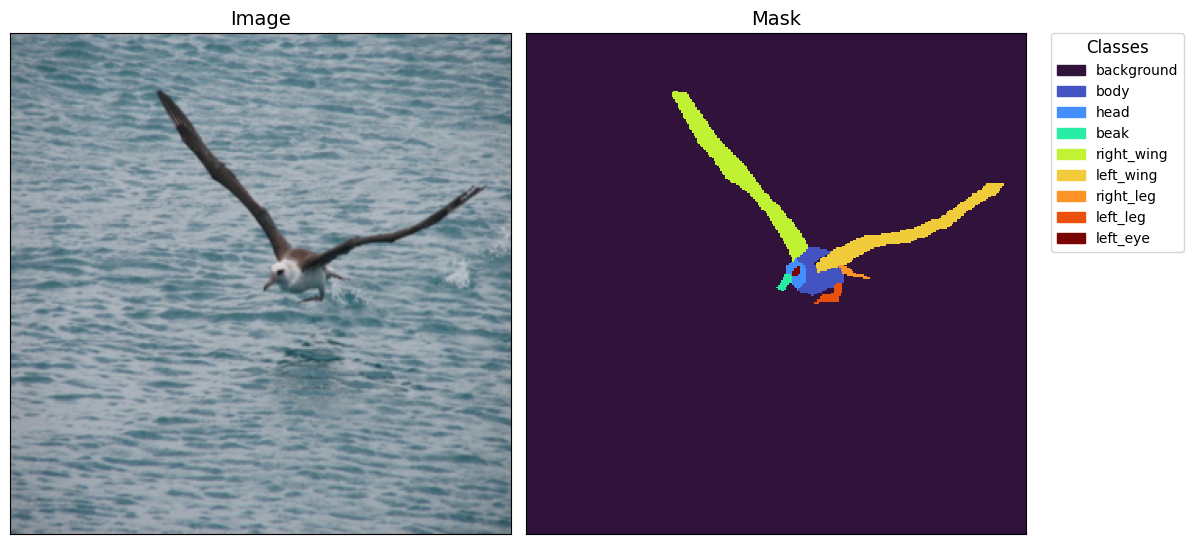

In [7]:
# Get sample image and mask
img, mask, class_id = full_dataset[30]
print(f"class_id: {class_id}")
visualize(labels=full_dataset.labels, image=img, mask=mask)

In [8]:
df = pd.read_csv(
            train_test_path,
            sep=" ", header=None, names=["img_id", "is_train"]
        )

official_train = df[df["is_train"] == 1]
official_test = df[df["is_train"] == 0]
official_train

,img_id,is_train
1,2,1
3,4,1
4,5,1
6,7,1
7,8,1
...,...,...
11777,11778,1
11780,11781,1
11781,11782,1
11783,11784,1


In [9]:
official_test

,img_id,is_train
0,1,0
2,3,0
5,6,0
9,10,0
11,12,0
...,...,...
11779,11780,0
11782,11783,0
11784,11785,0
11785,11786,0
